In [1]:
import numpy as np
import matplotlib.pyplot as plt
from settings import *
plt.style.use('aslak')
#import pandas as pd
#import xarray as xr

rhoi = 917

from grinsted_firn_model import *



c:\Users\ag\Documents\Python\firnmodel-1d\grinsted_firn_model.py:215: RuntimeWarning: divide by zero encountered in log
  logTamplitude[0] = np.log(Ts)


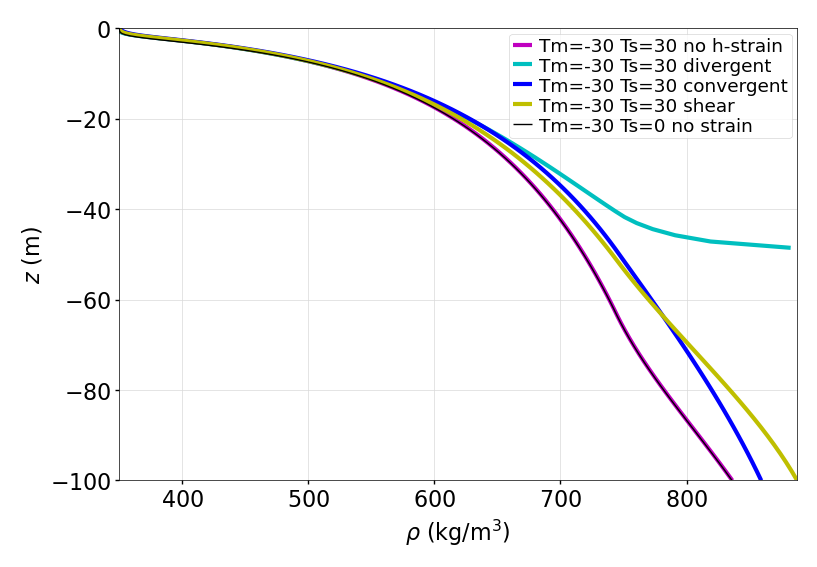

In [5]:

rho_s=350
bdot = 300 / sec_per_year #kg/m2/s
Tm = 273.15-30


z,rho = density_profile(Tm=Tm,Ts=30,bdot=bdot,rho_s=rho_s,e1=0,e2=0)
plt.plot(rho,-z,'m',label=f'Tm={Tm-273.15:.0f} Ts=30 no h-strain')
z,rho = density_profile(Tm=Tm,Ts=30,bdot=bdot,rho_s=rho_s,e1=0.005/sec_per_year,e2=0.005/sec_per_year)
plt.plot(rho,-z,'c',label=f'Tm={Tm-273.15:.0f} Ts=30 divergent')
z,rho = density_profile(Tm=Tm,Ts=30,bdot=bdot,rho_s=rho_s,e1=-0.005/sec_per_year,e2=-0.005/sec_per_year)
plt.plot(rho,-z,'b',label=f'Tm={Tm-273.15:.0f} Ts=30 convergent')
z,rho = density_profile(Tm=Tm,Ts=30,bdot=bdot,rho_s=rho_s,e1=0.005/sec_per_year,e2=-0.005/sec_per_year)
plt.plot(rho,-z,'y',label=f'Tm={Tm-273.15:.0f} Ts=30 shear')
z,rho = density_profile(Tm=Tm,Ts=0,bdot=bdot,rho_s=rho_s,e1=0,e2=0)
plt.plot(rho,-z,'k',label=f'Tm={Tm-273.15:.0f} Ts=0 no strain',lw=0.5)

plt.legend()

plt.xlabel('$\\rho$ ($\mathrm{kg/m^3}$)')
plt.ylabel('$z$ (m)')
plt.ylim([-100,0])

plt.savefig(os.path.join(figure_folder,'test.png'),dpi=200,bbox_inches='tight')

'/Users/ag/Documents/Papers/firnmodel-1d/figure\\test.png'

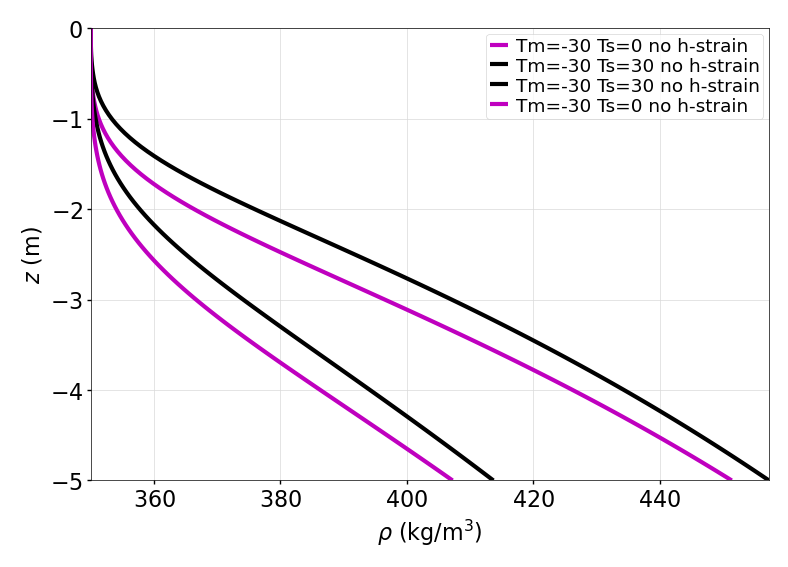

In [16]:

rho_s=350
bdot = 305 / sec_per_year #kg/m2/s
Tm = 273.15-30
z=np.linspace(0,5,100)

z,rho = density_profile(Tm=Tm,Ts=0,z=z,bdot=bdot,rho_s=rho_s,e1=0,e2=0)
plt.plot(rho,-z,'m',label=f'Tm={Tm-273.15:.0f} Ts=0 no h-strain')
z,rho = density_profile(Tm=Tm,Ts=30,z=z,bdot=bdot,rho_s=rho_s,e1=0,e2=0)
plt.plot(rho,-z,'k',label=f'Tm={Tm-273.15:.0f} Ts=30 no h-strain')
z,rho = density_profile(Tm=Tm,Ts=30,z=z,bdot=bdot*5,rho_s=rho_s,e1=0,e2=0)
plt.plot(rho,-z,'k',label=f'Tm={Tm-273.15:.0f} Ts=30 no h-strain')
z,rho = density_profile(Tm=Tm,Ts=0,z=z,bdot=bdot*5,rho_s=rho_s,e1=0,e2=0)
plt.plot(rho,-z,'m',label=f'Tm={Tm-273.15:.0f} Ts=0 no h-strain')


plt.legend()

plt.xlabel('$\\rho$ ($\mathrm{kg/m^3}$)')
plt.ylabel('$z$ (m)');


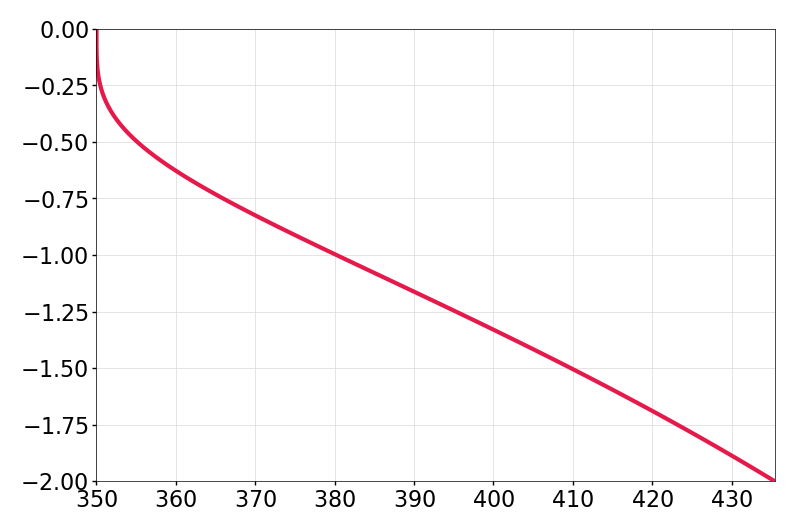

In [6]:
z,rho = density_profile(Tm=263,Ts=20,bdot=300 / sec_per_year,rho_s=350,e1=0,e2=0,z=np.linspace(0,2,100))
plt.plot(rho,-z)

In [ ]:

A_fun = A
A_fun = lambda T: np.exp(-130e3/(R*T)) 
def Abar_approx(Tm,Ts):
    curTs = Ts
    if curTs > 1e-3:
        dlogAdT = (
            np.log(A_fun(Tm + curTs)) - np.log(A_fun(Tm))
        ) / Ts  # The warm Q is the most important
        Qprime = dlogAdT * R * (Tm + curTs / 2) ** 2
        Q=Qprime
        #Ar = A_fun(Tm+Ts)
        #return Ar*(2**(1/2)*R**(1/2)*erf((2**(1/2)*Q**(1/2)*Ts**(1/2)*np.pi)/(2*R**(1/2)*(Tm + Ts)))*(Tm + Ts))/(2*Q**(1/2)*Ts**(1/2)*np.pi**(1/2))
        return (
            A_fun(Tm + curTs)
            * (Tm + curTs)
            * erf(np.pi * np.sqrt(0.5 * Qprime * curTs / R) / (Tm + curTs))
            / np.sqrt(2 * np.pi * Qprime * curTs / R)
        )
    else:
        return A_fun(Tm)

def Abar_sine(Tm,Ts):
    Q = 130e3
    Am = A_fun(Tm)
    return Am*((R**(1/2)*Tm**(3/2)*np.exp(Q/(4*R*Tm))*(erf((Q**(1/2)*(Tm + Ts*np.pi))/(2*R**(1/2)*Tm**(3/2))) - erf((Q**(1/2)*(Tm - Ts*np.pi))/(2*R**(1/2)*Tm**(3/2)))))/(2*Q**(1/2)*Ts*np.pi**(1/2)))

def Abar_cosine2(Tm,Ts):
    Q = 130e3
    Amax = A_fun(Tm+Ts)
    return Amax * (2**(1/2)*R**(1/2)*erf((2**(1/2)*Q**(1/2)*Ts**(1/2)*np.pi)/(2*R**(1/2)*(Tm + Ts)))*(Tm + Ts))/(2*Q**(1/2)*Ts**(1/2)*np.pi**(1/2))

        
def Abar_old(Tm,Ts):
    curTs = Ts
    if curTs > 1e-3:
        Tmprime = (
           Tm + 0.7 * curTs**2 / Tm
        )  # least elegant. Is it better to just numerically integrate?
        Am_prime = A_fun(Tmprime)  # eqn17
        dlogAdT = (
            np.log(A_fun(Tm + curTs)) - np.log(A_fun(Tm))
        ) / Ts  # The warm Q is the most important
        Qprime = dlogAdT * R * (Tm + curTs / 2) ** 2
        #Qprime = 130e3

        return Am_prime * np.real(jv(0, 1j * Qprime * curTs / (R * Tm**2)))
    else: 
        return A_fun(Tm)

def Abar_numerical(Tm,Ts,N=10000):
    T = Tm+Ts*np.cos(np.linspace(0,np.pi,N))
    return np.mean(A_fun(T))

Tm=273-40
Ts = 30
Am = A_fun(Tm)
Atrue = Abar_numerical(Tm,Ts)
print('cos-approx',Abar_approx(Tm,Ts)/Atrue)
print('cos-approx',Abar_cosine2(Tm,Ts)/Atrue)
print('sin-approx',Abar_sine(Tm,Ts)/Atrue)
print('old-approx',Abar_old(Tm,Ts)/Atrue)
print('numerical',Abar_numerical(Tm,Ts)/Atrue)
print('numerical-coarse',Abar_numerical(Tm,Ts,N=10)/Atrue)


cos-approx 0.9913269815889637
sin-approx 8.914151327182497
old-approx 5.326092414478295
numerical 1.0
numerical-coarse 1.2239379231702128


In [29]:
from scipy.special import erf
curTs = Ts
Qprime = 139e3
AAA = A_fun(Tm + curTs)* (Tm + curTs)* erf(np.pi * np.sqrt(2 * Qprime * curTs / R) / (Tm + curTs))/ np.sqrt(8 * np.pi * Qprime * curTs / R)
AAA / Am

7.411552676047382